In [63]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

from LoadMoments import *

In [64]:
# Plotting
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
linestyles = ['-', '--', '-.', ':']

# Some first plots

In [65]:
# Parameter
M = 4 #parse(Int, ARGS[1])
closure = "ExtGram" #ARGS[2] # String # "Gram", "ExtGram" or "Grad"
Kn = 1.0 #parse(Float64, ARGS[3])
# source_string = ARGS[4]
source_string = "relaxation_source"
# source = relaxation_source #zero_source #relaxation_source
T_end = 0.3 #parse(Float64, ARGS[5])
base_tree_level = 7 #!2 #parse(Int, ARGS[6]) # e.g. 8
polydeg = 1 #parse(Int, ARGS[7]) # e.g. 3
rho_L = 7.0 #parse(Float64, ARGS[8]) # 7.0
v_L1 = 0.0 #!1.0 #!1.5 #parse(Float64, ARGS[9]) # 0.0
v_L2 = 0.0
v_L3 = 0.0
theta_L = 1.0 #parse(Float64, ARGS[10]) # 1.0
rho_R = 1.0 #parse(Float64, ARGS[11]) # 1.0
v_R1 = 0.0 #!1.0 #parse(Float64, ARGS[12]) # 0.0
v_R2 = 0.0
v_R3 = 0.0
theta_R = 1.0 #parse(Float64, ARGS[13]) # 1.0
name = f"../out/1D3D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L1{v_L1}_v_L2{v_L2}_v_L3{v_L3}_v_R1{v_R1}_v_R2{v_R2}_v_R3{v_R3}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}"

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_4086/2498118703.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


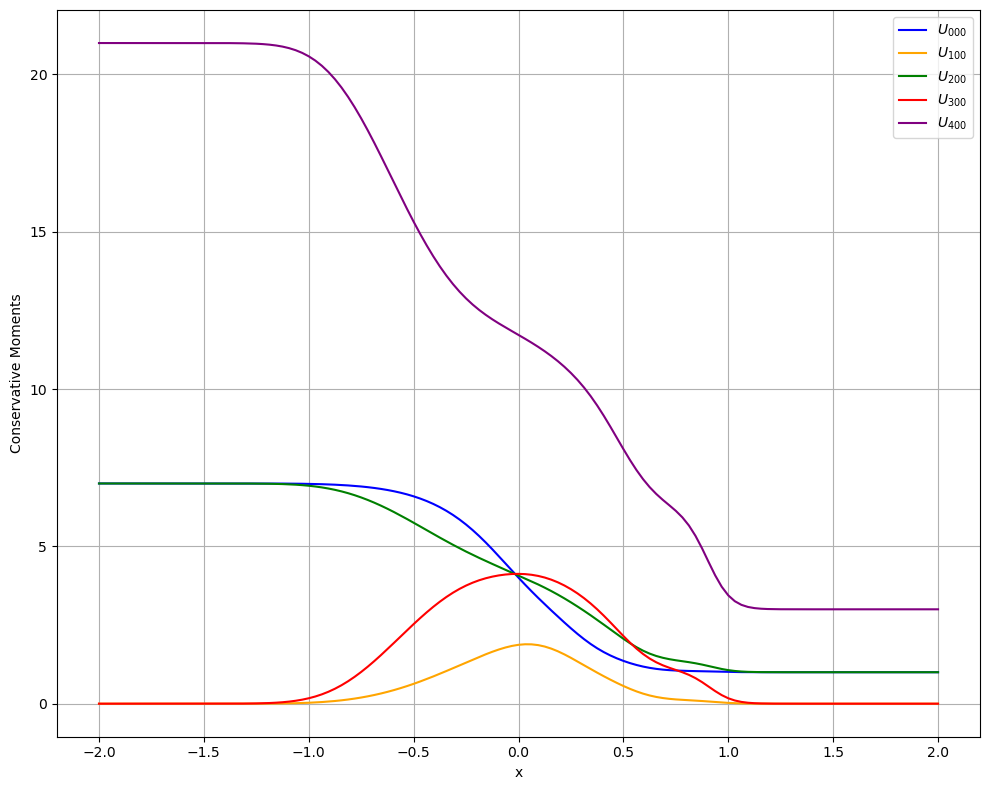

In [66]:
# Conservative Moments
data = read_solution_file(name + "_cons.tsv")

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, U, t = sol["x"], sol["u"], sol["t"]

fig, axs = plt.subplots(figsize=(10, 8))
axs.plot(x, U[:, 0], label="$U_{000}$", color=colors[0])
axs.plot(x, U[:, 1], label="$U_{100}$", color=colors[1])
axs.plot(x, U[:, 2], label="$U_{200}$", color=colors[2])
axs.plot(x, U[:, 4], label="$U_{300}$", color=colors[3])
axs.plot(x, U[:, 6], label="$U_{400}$", color=colors[4])
axs.set_xlabel("x")
axs.set_ylabel("Conservative Moments")
axs.grid(True)
axs.legend()
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/ConservativeMoments.pdf')
fig.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_4086/1207176404.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


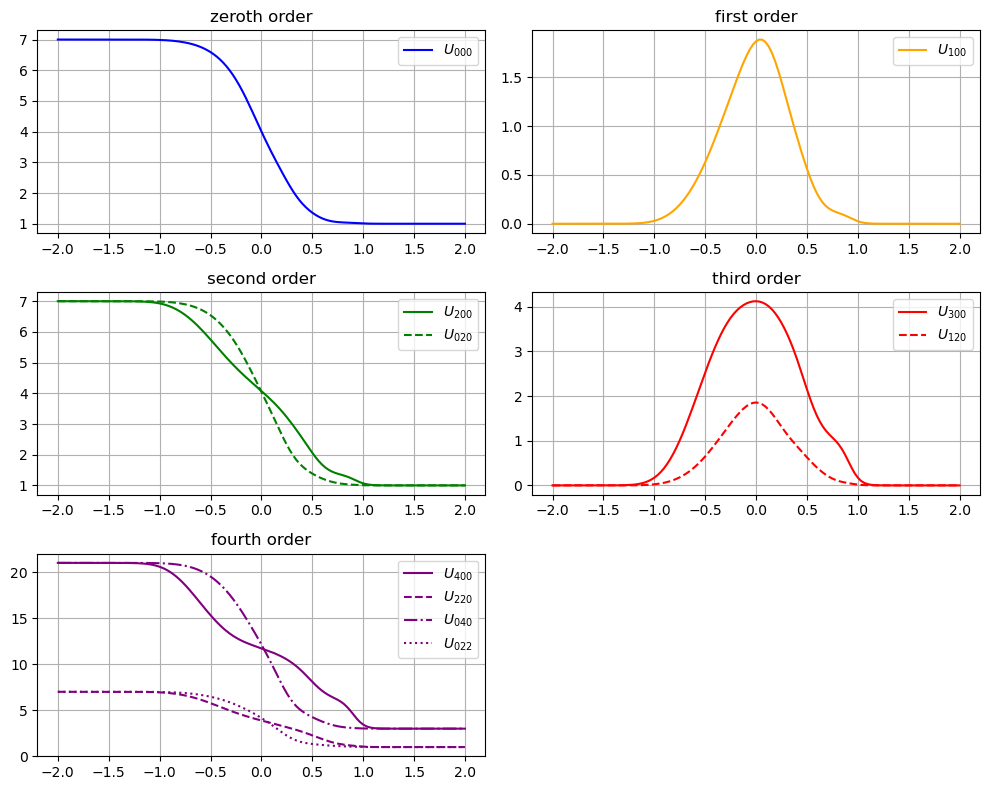

In [67]:
fig, axs = plt.subplots(3, 2, figsize=(10, 8))
axs[0, 0].plot(x, U[:, 0], label="$U_{000}$", color=colors[0], linestyle=linestyles[0])
axs[0, 0].set_title("zeroth order")
axs[0, 0].grid(True)
axs[0, 1].plot(x, U[:, 1], label="$U_{100}$", color=colors[1], linestyle=linestyles[0])
axs[0, 1].set_title("first order")
axs[0, 1].grid(True)
axs[1, 0].plot(x, U[:, 2], label="$U_{200}$", color=colors[2], linestyle=linestyles[0])
axs[1, 0].plot(x, U[:, 3], label="$U_{020}$", color=colors[2], linestyle=linestyles[1])
axs[1, 0].set_title("second order")
axs[1, 0].grid(True)
axs[1, 1].plot(x, U[:, 4], label="$U_{300}$", color=colors[3], linestyle=linestyles[0])
axs[1, 1].plot(x, U[:, 5], label="$U_{120}$", color=colors[3], linestyle=linestyles[1])
axs[1, 1].set_title("third order")
axs[1, 1].grid(True)
axs[2, 0].plot(x, U[:, 6], label="$U_{400}$", color=colors[4], linestyle=linestyles[0])
axs[2, 0].plot(x, U[:, 7], label="$U_{220}$", color=colors[4], linestyle=linestyles[1])
axs[2, 0].plot(x, U[:, 8], label="$U_{040}$", color=colors[4], linestyle=linestyles[2])
axs[2, 0].plot(x, U[:, 9], label="$U_{022}$", color=colors[4], linestyle=linestyles[3])
axs[2, 0].set_title("fourth order")
axs[2, 0].grid(True)
axs[2, 1].axis('off')
[ax.legend() for ax in axs.flat if ax.has_data()]
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/ConservativeMoments_Full.pdf')
fig.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_4086/1518321668.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


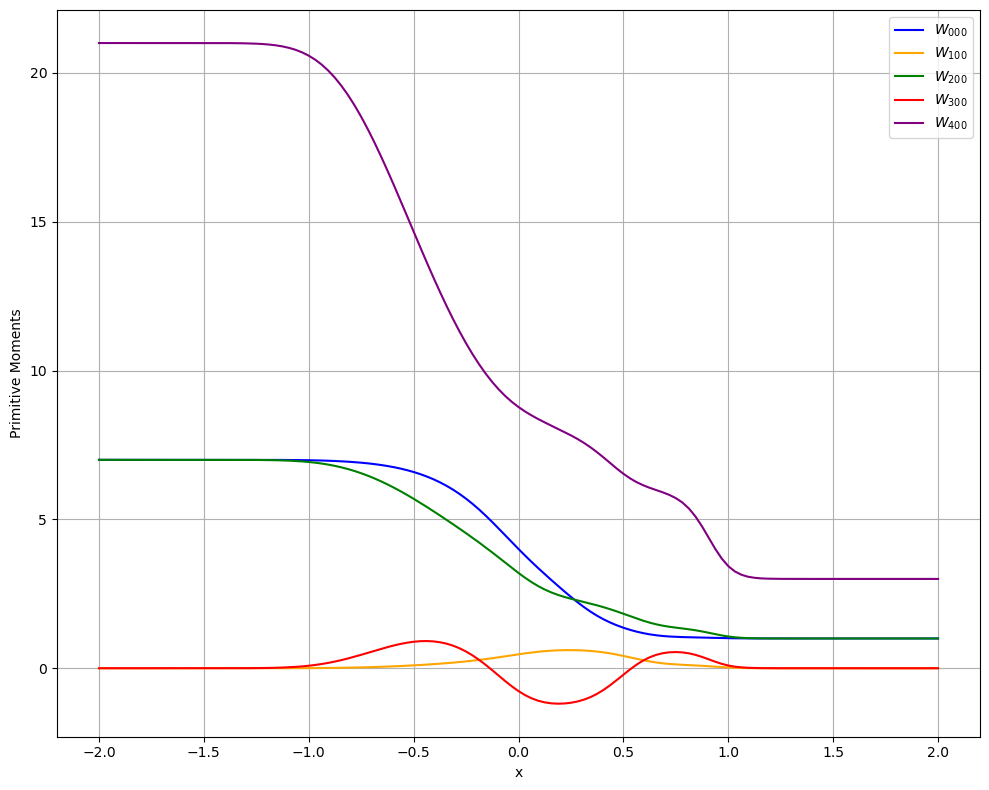

In [68]:
# Primitive Moments
data = read_solution_file(name + "_prim.tsv")

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, W, t = sol["x"], sol["u"], sol["t"]

fig, axs = plt.subplots(figsize=(10, 8))
axs.plot(x, W[:, 0], label="$W_{000}$", color=colors[0])
axs.plot(x, W[:, 1], label="$W_{100}$", color=colors[1])
axs.plot(x, W[:, 2], label="$W_{200}$", color=colors[2])
axs.plot(x, W[:, 4], label="$W_{300}$", color=colors[3])
axs.plot(x, W[:, 6], label="$W_{400}$", color=colors[4])
axs.set_xlabel("x")
axs.set_ylabel("Primitive Moments")
axs.grid(True)
axs.legend()
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/PrimitiveMoments.pdf')
fig.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_4086/2880951885.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


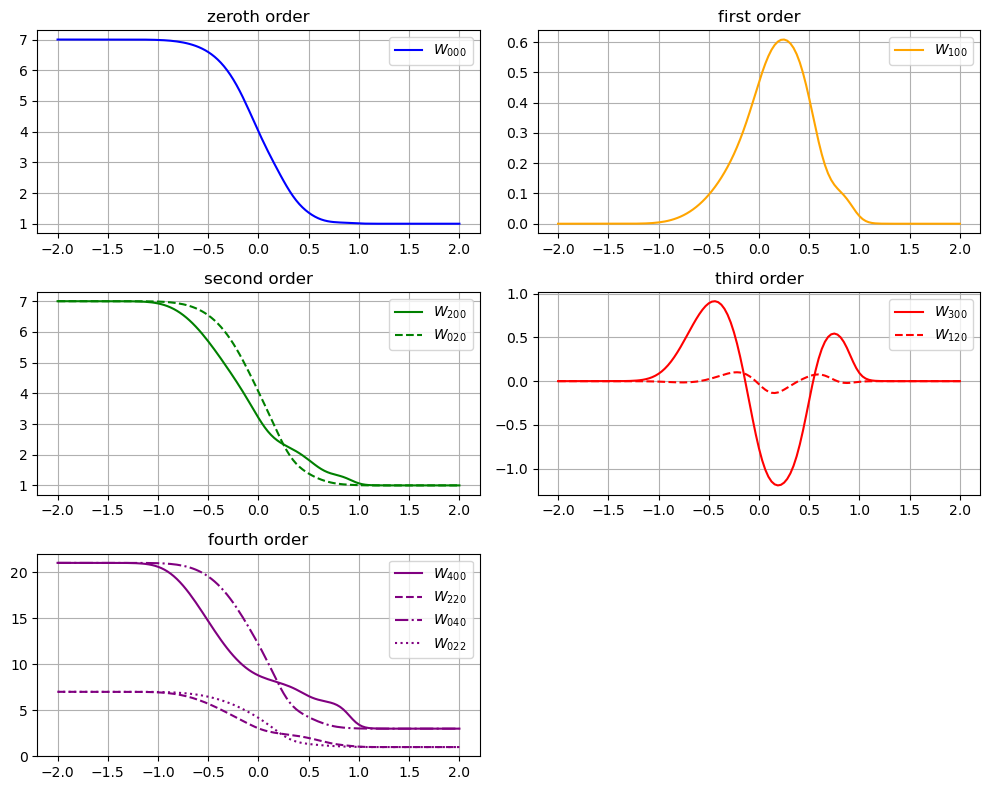

In [69]:
fig, axs = plt.subplots(3, 2, figsize=(10, 8))
axs[0, 0].plot(x, W[:, 0], label="$W_{000}$", color=colors[0], linestyle=linestyles[0])
axs[0, 0].set_title("zeroth order")
axs[0, 0].grid(True)
axs[0, 1].plot(x, W[:, 1], label="$W_{100}$", color=colors[1], linestyle=linestyles[0])
axs[0, 1].set_title("first order")
axs[0, 1].grid(True)
axs[1, 0].plot(x, W[:, 2], label="$W_{200}$", color=colors[2], linestyle=linestyles[0])
axs[1, 0].plot(x, W[:, 3], label="$W_{020}$", color=colors[2], linestyle=linestyles[1])
axs[1, 0].set_title("second order")
axs[1, 0].grid(True)
axs[1, 1].plot(x, W[:, 4], label="$W_{300}$", color=colors[3], linestyle=linestyles[0])
axs[1, 1].plot(x, W[:, 5], label="$W_{120}$", color=colors[3], linestyle=linestyles[1])
axs[1, 1].set_title("third order")
axs[1, 1].grid(True)
axs[2, 0].plot(x, W[:, 6], label="$W_{400}$", color=colors[4], linestyle=linestyles[0])
axs[2, 0].plot(x, W[:, 7], label="$W_{220}$", color=colors[4], linestyle=linestyles[1])
axs[2, 0].plot(x, W[:, 8], label="$W_{040}$", color=colors[4], linestyle=linestyles[2])
axs[2, 0].plot(x, W[:, 9], label="$W_{022}$", color=colors[4], linestyle=linestyles[3])
axs[2, 0].set_title("fourth order")
axs[2, 0].grid(True)
axs[2, 1].axis('off')
[ax.legend() for ax in axs.flat if ax.has_data()]
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/PrimitiveMoments_Full.pdf')
fig.show()

# Different angle pairs

In [70]:
closure = 'ExtGram'
Kn = 1.0
T_end = 0.3
name = lambda anglepair: f"../out/1D3D/1D3D_angles/gram_solution_1D3D_closure{closure}_Kn{Kn}_anglepairnumber{anglepair}_Tend{T_end}_cons.tsv"

marker = ['o', 's', '^', 'x', 'd']

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_4086/434875265.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


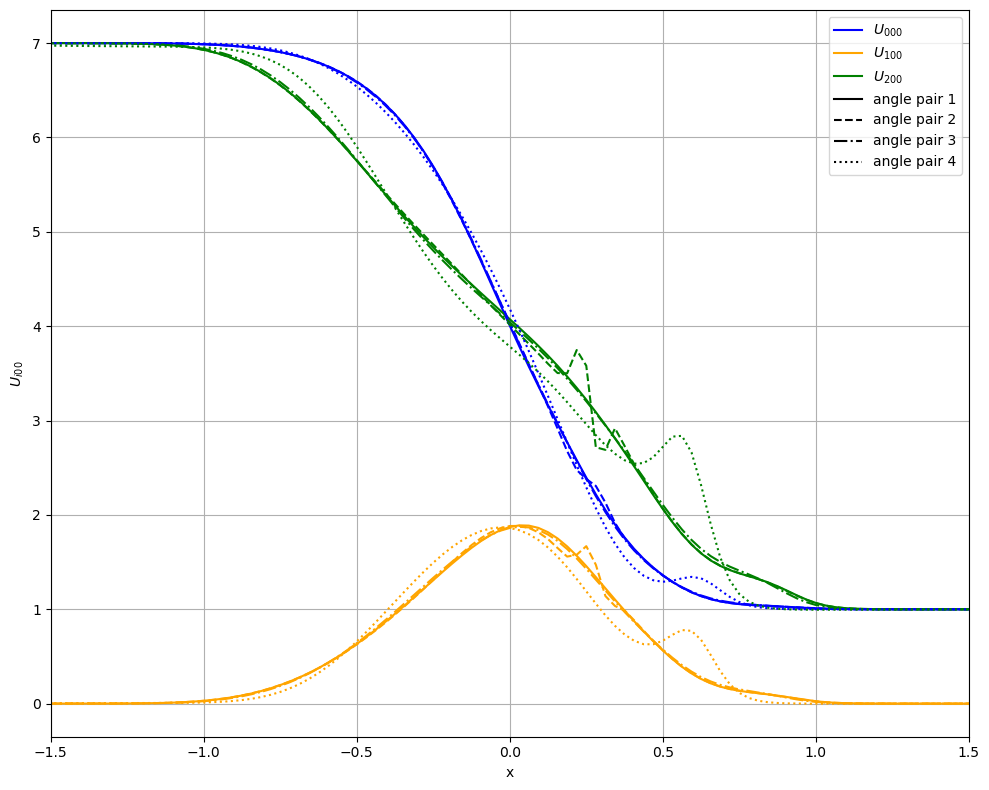

In [85]:
# Conservative Moments
fig, axs = plt.subplots(figsize=(10, 8))
# names = [name(i) for i in range(1,6)]
# names = [name(1), name(2), name(3), name(5)]
names = [name(1), name(2), name(3), name(5)]
for i, solution_file in enumerate(names):

    data = read_solution_file(solution_file)

    # Build time → timestep mapping
    times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
    timesteps = np.array(sorted(data.keys()))

    time_query = 21 # last time step
    sol = interpolate_solution(data, time_query, times, timesteps)
    x, U, t = sol["x"], sol["u"], sol["t"]

    axs.plot(x, U[:, 0], color=colors[0], linestyle=linestyles[i])
    axs.plot(x, U[:, 1], color=colors[1], linestyle=linestyles[i])
    axs.plot(x, U[:, 2], color=colors[2], linestyle=linestyles[i])
    # axs.plot(x, U[:, 4], color=colors[3], linestyle=linestyles[i])
    # axs.plot(x, U[:, 6], color=colors[4], linestyle=linestyles[i])
labels = ['$U_{000}$', '$U_{100}$', '$U_{200}$']
[axs.plot([], [], color=colors[i], linestyle='-', label=label) for i, label in enumerate(labels)]
[axs.plot([], [], color='black', linestyle=linestyles[i], label=f'angle pair {i+1}') for i in range(4)]
axs.set_xlabel("x")
axs.set_ylabel("$U_{i00}$")
axs.grid(True)
axs.legend()
axs.set_xlim(-1.5, 1.5)
fig.tight_layout()
fig.savefig('../out/Figures/1D3D/CompareAnglePairs.pdf')
fig.show()